# Portfolio scenario comparison | 2015–2025

This notebook compares the original diversified portfolio with **5% Bitcoin**, **technology-heavy**, and **dividend-focused** variants, plus a 60/40 benchmark. All five use **the same January 2015–December 2025 return window**, a $10,000 starting value, and monthly rebalancing. December 2014 prices establish the first monthly return. The original [2011–2025 notebook](portfolio_visual_analysis.ipynb) remains a separate full-history analysis.

Run from the project folder so Python can import `scenario_comparison.py`. If needed, run `%pip install -r requirements.txt` in a notebook cell and restart the kernel. No CSV files are overwritten.

**Method:** Yahoo Finance adjusted monthly closes via `yfinance`; distributions are reflected in adjusted ETF prices. Bitcoin uses the `BTC-USD` spot-price proxy and produces no dividend income. Bitcoin trades continuously, while ETFs trade on exchange days, so month-end timing is not perfectly synchronous. Returns exclude taxes, fund expenses beyond those reflected in ETF prices, trading costs, slippage, inflation, and cash flows. Results are hypothetical and retrospective.

## 1. Allocation choices

| Portfolio | VTI | VEA | BND | GLD | VNQ | SHY | BTC-USD | VGT | SCHD | VYM |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Diversified core | 40% | 15% | 25% | 10% | 5% | 5% | — | — | — | — |
| Core + 5% Bitcoin | 35% | 15% | 25% | 10% | 5% | 5% | 5% | — | — | — |
| Technology heavy | 20% | — | 10% | — | — | 5% | — | 65% | — | — |
| Dividend focus | — | — | 20% | — | — | 5% | — | — | 50% | 25% |
| 60/40 benchmark | 60% | — | 40% | — | — | — | — | — | — | — |

The Bitcoin variant funds its 5% position by reducing VTI from 40% to 35%. VGT is a concentrated US information technology ETF, so the technology portfolio also has substantial US stock exposure through VTI. SCHD and VYM are dividend-oriented stock funds; **“dividend focus” refers to the holdings, not a promise of higher total return or a calculation of cash yield**. The portfolio returns assume distributions are reinvested.

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from scenario_comparison import PORTFOLIOS, load_monthly_prices, run_comparison, performance_summary

plt.rcParams.update({'figure.figsize': (12, 5.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': .22})
colors = {'Diversified core': '#0f766e', 'Core + 5% Bitcoin': '#7c3aed',
          'Technology heavy': '#2563eb', 'Dividend focus': '#d97706',
          '60/40 benchmark': '#64748b'}
prices = load_monthly_prices()
asset_returns, returns, wealth = run_comparison(prices)
summary = performance_summary(returns, wealth)
annual = (1 + returns).groupby(returns.index.year).prod().sub(1)
drawdown = wealth.div(wealth.cummax().clip(lower=10000)).sub(1)
print(f'{len(returns)} common monthly returns: {returns.index[0]}–{returns.index[-1]}')


## 2. Comparable risk and return statistics

CAGR is compound annual growth. Volatility is the sample standard deviation of monthly returns × √12. The Sharpe-style ratio uses a **0% risk-free rate** for comparability. Maximum drawdown is measured at month end, so intramonth losses may be larger.

In [ ]:
shown = summary.copy().astype(object)
shown['Ending value'] = summary['Ending value'].map(lambda x: f'${x:,.0f}')
for column in ('CAGR', 'Volatility', 'Max drawdown', 'Positive months'):
    shown[column] = summary[column].map(lambda x: f'{x:.2%}')
shown['Sharpe (0% RF)'] = summary['Sharpe (0% RF)'].map(lambda x: f'{x:.2f}')
display(shown)


## 3. Growth of $10,000

These curves show total return with distributions reinvested for ETFs. A higher ending value does not by itself identify the best portfolio for a moderate-risk client.

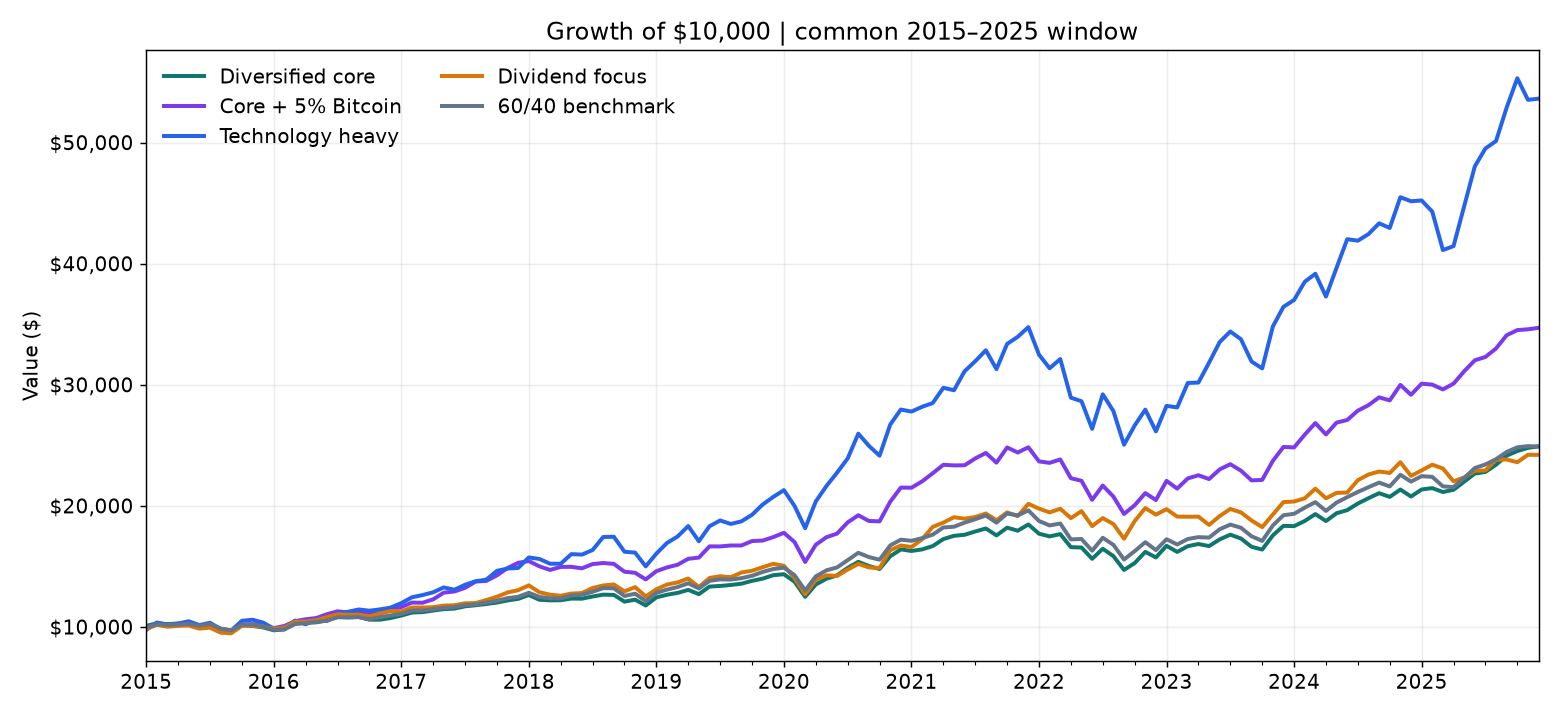

In [3]:
ax = wealth.plot(color=[colors[c] for c in wealth.columns], linewidth=2.2)
ax.set(title='Growth of $10,000 | common 2015–2025 window', xlabel='', ylabel='Value ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## 4. Depth of losses

Drawdown measures loss from the previous month-end peak, including the initial $10,000. Compare the depth and recovery path, not just the single worst value.

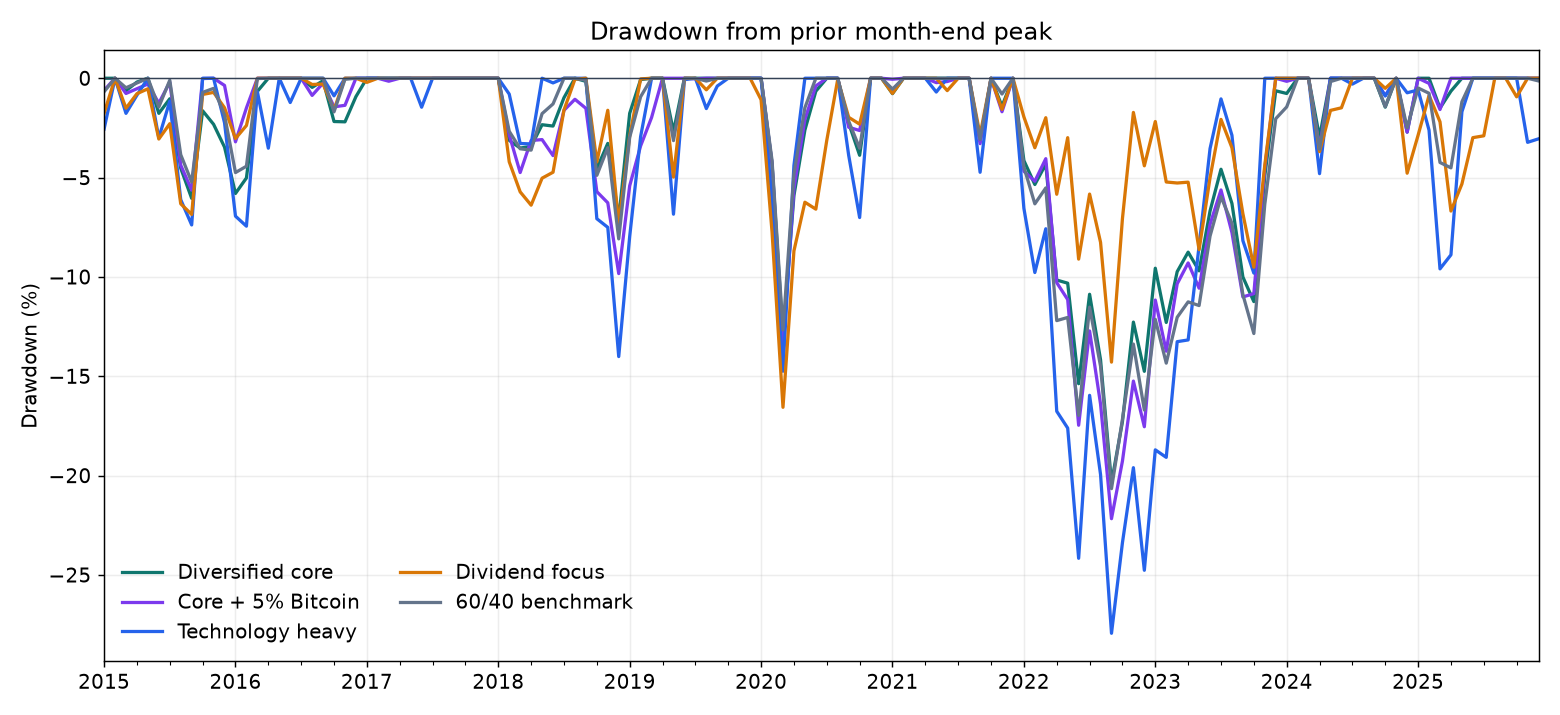

In [4]:
ax = drawdown.mul(100).plot(color=[colors[c] for c in drawdown.columns], linewidth=1.8)
ax.set(title='Drawdown from prior month-end peak', xlabel='', ylabel='Drawdown (%)')
ax.axhline(0, color='#334155', linewidth=.8)
ax.legend(loc='lower left', frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## 5. Annual return heatmap

Each cell compounds that calendar year’s twelve monthly returns. This exposes whether a portfolio’s advantage came from many years or a few unusually strong years. The shared dates prevent an unfair comparison caused by Bitcoin’s shorter available history.

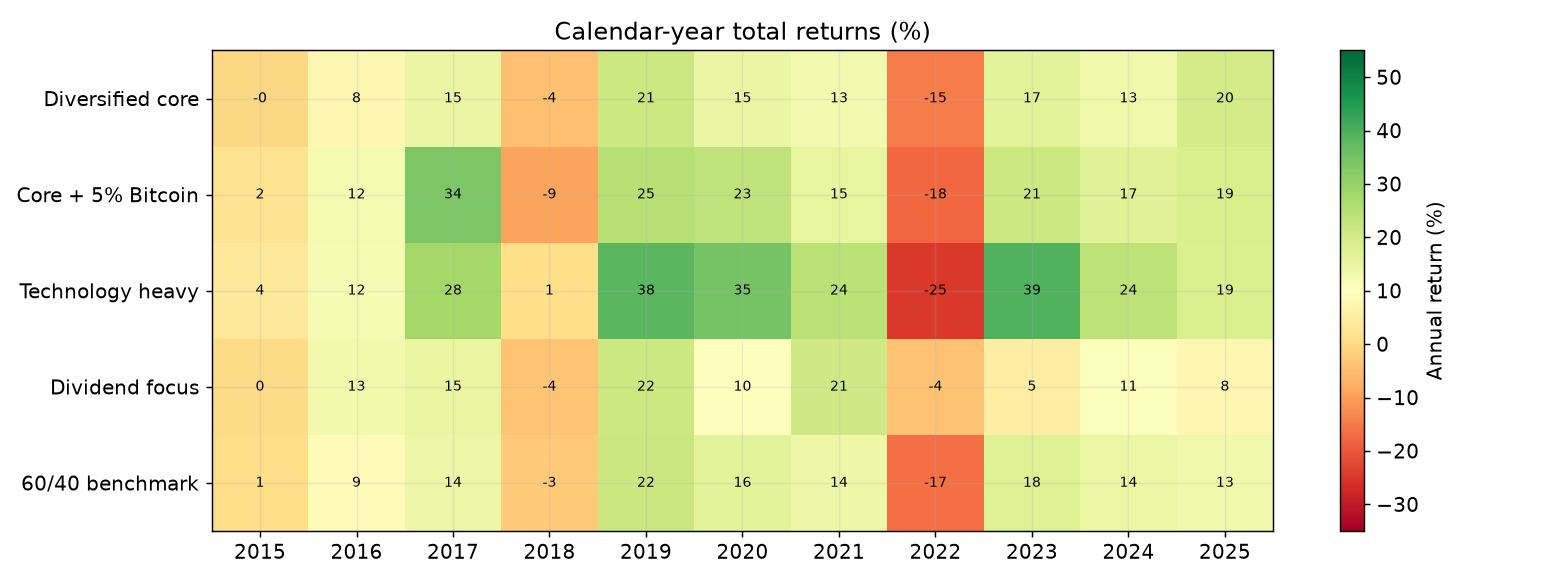

In [5]:
matrix = annual.T.mul(100)
fig, ax = plt.subplots(figsize=(12, 4.5))
image = ax.imshow(matrix, cmap='RdYlGn', vmin=-35, vmax=55, aspect='auto')
ax.set_xticks(range(len(matrix.columns)), matrix.columns)
ax.set_yticks(range(len(matrix.index)), matrix.index)
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax.text(j, i, f'{matrix.iloc[i, j]:.0f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='Annual return (%)')
ax.set_title('Calendar-year total returns (%)')
plt.tight_layout()
plt.show()


## 6. Return versus volatility

The scatter plot makes the growth–risk tradeoff easier to see. Volatility is only one risk measure; review the drawdown chart as well.

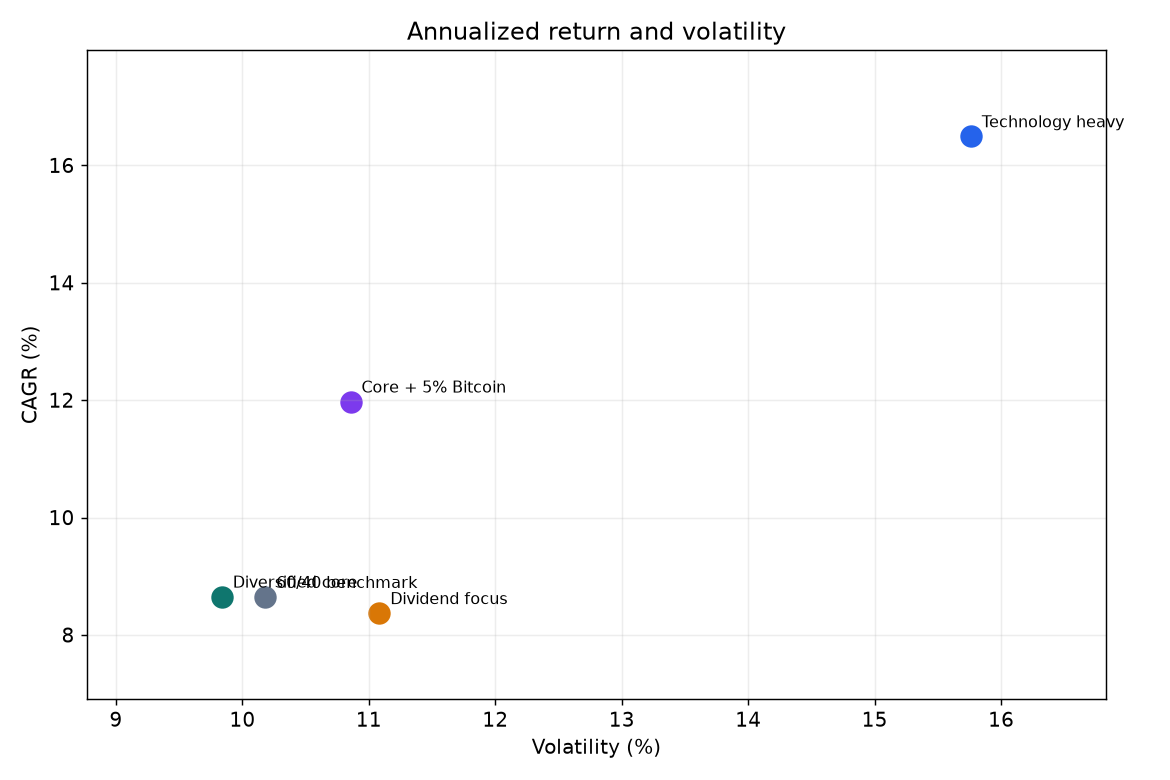

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, row in summary.iterrows():
    ax.scatter(row['Volatility'] * 100, row['CAGR'] * 100,
               s=130, color=colors[name], label=name)
    ax.annotate(name, (row['Volatility'] * 100, row['CAGR'] * 100),
                xytext=(6, 5), textcoords='offset points', fontsize=9)
ax.set(title='Annualized return and volatility', xlabel='Volatility (%)', ylabel='CAGR (%)')
ax.margins(.18)
plt.tight_layout()
plt.show()


## 7. Interpret the differences

The statements below are calculated from the current download, so they update when data or allocations change.

In [ ]:
core = summary.loc['Diversified core']
crypto = summary.loc['Core + 5% Bitcoin']
tech = summary.loc['Technology heavy']
dividend = summary.loc['Dividend focus']
print(f"Bitcoin sleeve: CAGR change {crypto['CAGR'] - core['CAGR']:+.2%}; "
      f"volatility change {crypto['Volatility'] - core['Volatility']:+.2%}; "
      f"worst drawdown {crypto['Max drawdown']:.2%} versus {core['Max drawdown']:.2%} for the core.")
print(f"Technology heavy: CAGR {tech['CAGR']:.2%} versus {core['CAGR']:.2%} for the core; "
      f"worst drawdown {tech['Max drawdown']:.2%} versus {core['Max drawdown']:.2%}.")
print(f"Dividend focus: CAGR {dividend['CAGR']:.2%} and worst drawdown "
      f"{dividend['Max drawdown']:.2%}. These are reinvested total returns, not cash-income figures.")
print(f"2022 returns: core {annual.loc[2022, 'Diversified core']:.2%}, "
      f"Bitcoin variant {annual.loc[2022, 'Core + 5% Bitcoin']:.2%}, "
      f"technology heavy {annual.loc[2022, 'Technology heavy']:.2%}, "
      f"dividend focus {annual.loc[2022, 'Dividend focus']:.2%}.")


### Reading the result responsibly

The **5% Bitcoin** result is especially sensitive to the chosen start date, large historical Bitcoin gains, and the monthly rebalancing rule. The **technology-heavy** portfolio concentrates risk in one sector and in US equities. The **dividend-focused** portfolio may appeal to an income preference, but this notebook measures *reinvested total return*, not dividend cash flow, yield stability, or after-tax income. None of the portfolios was optimized or selected from an out-of-sample test.

**Sources:** [Yahoo Finance BTC-USD history](https://finance.yahoo.com/quote/BTC-USD/history/), [Schwab SCHD fund profile](https://www.schwabassetmanagement.com/products/schd), [Vanguard ETF list for VGT and VYM](https://investor.vanguard.com/investment-products/list/etfs). The backtest uses Yahoo Finance adjusted ETF prices retrieved through `yfinance`; provider revisions can change results.